In [1]:
import numpy as np
import healpy as hp
from matplotlib.pyplot import *
from scipy.optimize import curve_fit
import pickle
# from cmblensplus/wrap/
import curvedsky as cs
# from cmblensplus/utils/
import cmb as CMB
import plottools as pl
import constant as c
import analysis as ana
import binning as bn
# others
import local
import tools_multitracer as mass
import tools_delens
import tools_cmb
import warnings
warnings.filterwarnings("ignore")

In [2]:
import importlib
importlib.reload(tools_delens)

<module 'tools_delens' from '/global/u1/t/toshiyan/Work/Ongoing/litebird/project-lens/tools_delens.py'>

In [3]:
def pdf_gauss(xs, amp, mean, sigma):
    return amp*np.exp(-(xs-mean)**2/(2*sigma**2))

In [4]:
simn = 250
num = 250
lbmin, lbmax = 2, 190
bN = 20
area = 'lbonly'
#area = 'lbfull'
#area = 'lbs4'
method = 'cinv'
#method = 'bonly'
wmass = 'all'

In [5]:
pobj = local.analysis()
cobj = tools_cmb.cmb_map()
dobj = tools_delens.filename(method=method)

In [6]:
mask = tools_cmb.prepare_masks()
Fsky = {m: np.average(mask[m]) for m in tools_cmb.masks}
mb = bn.multipole_binning(bN,lmin=lbmin,lmax=lbmax,lstart=lbmin,spc='')
L = np.linspace(0,lbmax,lbmax+1)

In [7]:
# range of r
rs = np.arange(-7e-3+40*5e-5,7e-3,5e-5)
x = 1e3*rs

In [8]:
# define fsky
fsky = Fsky[area]
print(fsky)
# read cls
Ol = np.zeros((simn,lbmax+1-lbmin))
Rl = np.zeros((simn,lbmax+1-lbmin))
Ll = np.zeros((simn,lbmax+1-lbmin))
Xl = np.zeros((simn,lbmax+1-lbmin))
Ob = np.zeros((simn,bN))
Rb = np.zeros((simn,bN))
Lb = np.zeros((simn,bN))
Xb = np.zeros((simn,bN))
for rlz in range(1,simn+1):
    obb, rbb, lbb, xbb = np.loadtxt(dobj.cl[area][wmass][rlz],usecols=(0,1,2,3),unpack=True)[:,lbmin:lbmax+1]
    Ol[rlz-1,:] = obb/fsky
    Rl[rlz-1,:] = rbb/fsky
    Ll[rlz-1,:] = lbb/fsky
    Xl[rlz-1,:] = xbb/fsky
    Ob[rlz-1,:] = bn.binning(obb,mb)/fsky
    Rb[rlz-1,:] = bn.binning(rbb,mb)/fsky
    Lb[rlz-1,:] = bn.binning(lbb,mb)/fsky
    Xb[rlz-1,:] = bn.binning(xbb,mb)/fsky
# obtain averaged cls over rlz
mOl = np.mean(Ol,axis=0)
mRl = np.mean(Rl,axis=0)
mLl = np.mean(Ll,axis=0)
mXl = np.mean(Xl,axis=0)
mOb = np.mean(Ob,axis=0)
mRb = np.mean(Rb,axis=0)
mLb = np.mean(Lb,axis=0)
mXb = np.mean(Xb,axis=0)
# compute delensed cls
mAl = mXl/mLl
mAb = mXb/mLb
Dl = Ol - 2*mAl*Xl + mAl**2*Ll
Db = Ob - 2*mAb*Xb + mAb**2*Lb
mDl = np.mean(Dl,axis=0)
# compute PDF
lnLo = np.zeros((num,len(rs)))
lnLd = np.zeros((num,len(rs)))
for rlz in range(num):
    obb0, lbb0, xbb0 = np.loadtxt(dobj.cl[area][wmass][simn+rlz+1],usecols=(0,2,3),unpack=True)[:,lbmin:lbmax+1]
    oOb = bn.binning(obb0/fsky,mb)
    oDb = oOb - 2*mAb*bn.binning(xbb0/fsky,mb) + mAb**2*bn.binning(lbb0/fsky,mb)
    lnLo[rlz,:] = tools_delens.compute_HL_r(oOb,Ob,mRb,rs)
    lnLd[rlz,:] = tools_delens.compute_HL_r(oDb,Db,mRb,rs)
PDFo = np.array( [ np.exp(lnLo[rlz]-np.max(lnLo[rlz])) for rlz in range(num) ] )
PDFd = np.array( [ np.exp(lnLd[rlz]-np.max(lnLd[rlz])) for rlz in range(num) ] )

0.17913786337122228


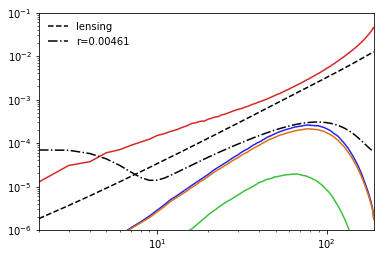

In [9]:
xlim(2,lbmax)
ylim(1e-6,1e-1)
Lfac = c.Tcmb**2*L[lbmin:]*(L[lbmin:]+1)/(2*np.pi)
loglog(L[lbmin:],Lfac*mOl)
#loglog(L[lbmin:],Lfac*mXl)
#loglog(L[lbmin:],Lfac*mLl)
loglog(L[lbmin:],Lfac*mDl)
loglog(L[lbmin:],Lfac*mRl*0.00461)
loglog(L[lbmin:],Lfac*pobj.clfg[lbmin:lbmax+1])
loglog(L[lbmin:],Lfac*pobj.lcl[2][lbmin:lbmax+1],label='lensing',color='k',ls='--')
loglog(L[lbmin:],Lfac*pobj.tcl[2][lbmin:lbmax+1]*0.00461,label='r=0.00461',color='k',ls='-.')
legend()

### obtain sigma(r) as a sigma of an r-estimator

In [10]:
resto = np.zeros(num)
restd = np.zeros(num)
for rlz in range(num):
    obb0, lbb0, xbb0 = np.loadtxt(dobj.cl[area][wmass][simn+rlz+1],usecols=(0,2,3),unpack=True)[:,lbmin:lbmax+1]
    oOb = bn.binning(obb0/fsky,mb)
    oDb = oOb - 2*mAb*bn.binning(xbb0/fsky,mb) + mAb**2*bn.binning(lbb0/fsky,mb)
    resto[rlz] = tools_delens.simple_r(oOb,Ob,mRb)
    restd[rlz] = tools_delens.simple_r(oDb,Db,mRb)

In [11]:
print(np.std(resto))
print(np.std(restd))

0.002264735256669123
0.0020316310617236716


### obtain sigma(r) assuming a Gaussian posterior

In [12]:
osigma = np.zeros((num,3))
dsigma = np.zeros((num,3))
for rlz in range(num):
    #osigma[rlz,0] = rs[ np.argmax( np.exp(lnLo[rlz]-np.max(lnLo[rlz])) ) ]
    #dsigma[rlz,0] = rs[ np.argmax( np.exp(lnLd[rlz]-np.max(lnLd[rlz])) ) ]
    osigma[rlz,:], __ = curve_fit(pdf_gauss, x, PDFo[rlz] )
    dsigma[rlz,:], __ = curve_fit(pdf_gauss, x, PDFd[rlz] )

In [13]:
print('amp, mean, sigma of pdf_gauss',np.mean(osigma,axis=0))
print('amp, mean, sigma of pdf_gauss',np.mean(dsigma,axis=0))
print('no delensing:',np.std(osigma[:,1]))
print('delensing:',np.std(dsigma[:,1]))

amp, mean, sigma of pdf_gauss [0.99994279 0.24382026 2.08113915]
amp, mean, sigma of pdf_gauss [0.99905947 0.23543951 1.65729306]
no delensing: 2.268021413278521
delensing: 2.0201883578695083


### compare PDF and its curve_fit

2.2850561943657244
1.8409769712285668


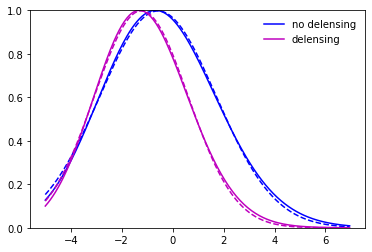

In [14]:
#xlim(-7,7)
rlz = 7
ylim(0,1)
popto, __ = curve_fit(pdf_gauss, x, PDFo[rlz])
print(popto[2])
poptd, __ = curve_fit(pdf_gauss, x, PDFd[rlz])
print(poptd[2])
plot(x,PDFo[rlz],label='no delensing',color='b')
plot(x,pdf_gauss(x, popto[0], popto[1], popto[2]),color='b',ls='--')
plot(x,PDFd[rlz],label='delensing',color='m')
plot(x,pdf_gauss(x, poptd[0], poptd[1], poptd[2]),color='m',ls='--')
legend()

In [15]:
if area == 'lbonly':
    Resto = {}
    Restd = {}
    Resto['lbonly'] = resto
    Restd['lbonly'] = restd

In [16]:
if area == 'lbs4':
    Resto['lbs4'] = resto
    Restd['lbs4'] = restd
Rest_o = (Resto['lbs4']/np.std(Resto['lbs4'])**2 + Resto['lbonly']/np.std(Resto['lbonly'])**2)/(1./np.std(Resto['lbs4'])**2 + 1./np.std(Resto['lbonly'])**2)
Rest_d = (Restd['lbs4']/np.std(Restd['lbs4'])**2 + Restd['lbonly']/np.std(Restd['lbonly'])**2)/(1./np.std(Restd['lbs4'])**2 + 1./np.std(Restd['lbonly'])**2)

KeyError: 'lbs4'